# Among adults with T2DM initiating Metformin monotherapy, what demographic and clinical characteristics are associated with the _timing_ of second-line antidiabetic therapy initiation?

**Study Design:** Descriptive observational study of metformin users who subsequently initiated second-line antidiabetic therapy. Time to escalation is measured from the metformin index date to the first non-metformin antidiabetic prescription. 

**Cohort**: Extracted from SynPUF 5% using ATLAS and the query in `Scripts/cohort_raw.sql`. 334 days of data from `2009-01-15` - `2009-12-15`. Inclusion criteria:

- Must have T2DM.
- Must have a second-line drug initiated in the study period.
- Must be an adult (18+)
- No pregnancy 9 months before the start of, _and_ 60 days before the end of the study period (to prevent inclusion of gestational diabetes.) -- We are allowing people to get pregnant 2 months before the study end date.

**Covariates**:

- Age
- Sex
- Ethnicity
- CKD
- CHD
- Hypertension
- Depression
- Diabetes Duration

**Team:** Giselle Feng (`fg2618`) and Nikhil Anand (`na3213`)

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 120,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)

# Step 1 : Data Loading and Cleaning

In [47]:
def clean_and_prepare(filepath):
    """
    Load raw drug-exposure-level data and return two DataFrames:
      1. df_raw  — all exposures within the study window (for pathway analysis)
      2. df      — one row per patient, first escalation event (for survival analysis)
    """

    raw = pd.read_csv(filepath)
    print(f"Raw data: {len(raw)} rows, {raw['person_id'].nunique()} unique patients")

    # --- Parse dates ---
    date_cols = [
        "cohort_start_date",
        "cohort_end_date",
        "observation_period_start_date",
        "observation_period_end_date",
        "second_line_start_date",
        "second_line_end_date",
        "censor_date",
    ]
    for col in date_cols:
        raw[col] = pd.to_datetime(raw[col], errors="coerce")

    # --- Drop exposures outside the study window ---
    before = len(raw)
    raw = raw[raw["second_line_start_date"] <= raw["cohort_end_date"]].copy()
    dropped = before - len(raw)
    print(f"Dropped {dropped} exposures after study end date (cohort_end_date)")
    print(f"Remaining: {len(raw)} exposures, {raw['person_id'].nunique()} patients")

    # --- Standardize ---
    raw["second_line_drug_name"] = raw["second_line_drug_name"].str.strip().str.lower()
    raw["gender"] = raw["gender"].str.strip().str.upper()
    raw["race"] = raw["race"].str.strip()
    raw["ethnicity"] = raw["ethnicity"].str.strip()

    # --- Days from metformin start to each exposure ---
    raw["days_to_drug"] = (
        raw["second_line_start_date"] - raw["cohort_start_date"]
    ).dt.days

    # --- Flag anomalies ---
    neg = raw[raw["days_to_drug"] < 0]
    if len(neg) > 0:
        print(f"WARNING: {len(neg)} exposures with negative time. Removing.")
        raw = raw[raw["days_to_drug"] >= 0].copy()

    same_day = raw[raw["days_to_drug"] == 0]
    if len(same_day) > 0:
        print(
            f"NOTE: {len(same_day)} exposures on day 0 (same day as metformin start)."
        )

    # --- Study period length ---
    raw["study_period_days"] = (
        raw["cohort_end_date"] - raw["cohort_start_date"]
    ).dt.days

    # --- Save cleaned full dataset for pathway analysis ---
    df_raw = raw.copy()

    # --- Collapse to one row per patient: first second-line event ---
    raw = raw.sort_values(["person_id", "second_line_start_date"])
    df = raw.groupby("person_id").first().reset_index()

    # --- Time to first escalation ---
    df["time_to_escalation"] = (
        df["second_line_start_date"] - df["cohort_start_date"]
    ).dt.days

    print(
        "Number of records with zero time to escalation days",
        len(df[df["time_to_escalation"] == 0]),
    )
    print("These will be pruned!")
    df = df[df["time_to_escalation"] > 0]

    # --- Diabetes Duration ---
    df = df[df["diabetes_duration_days"] > 0]
    df["diabetes_duration"] = pd.cut(
        df["diabetes_duration_days"],
        bins=[0, 90, 180, 365, 650],
        labels=["0–3 mo", "3–6 mo", "6–12 mo", "1–2+ yr"],
    )
    df["diabetes_duration"] = pd.Categorical(
        df["diabetes_duration"],
        categories=["0–3 mo", "3–6 mo", "6–12 mo", "1–2+ yr"],
        ordered=True,
    )

    # --- Event indicator (all = 1, everyone escalated) ---
    df["event"] = 1

    # --- Age groups ---
    df["age_group"] = pd.cut(
        df["age_at_index"],
        bins=[17, 44, 64, 74, 120],
        labels=["18-44", "45-64", "65-74", "75+"],
    )

    # --- Rename flags ---
    df = df.rename(
        columns={
            "hypertension_flag": "hypertension",
            "depression_flag": "depression",
            "chd_flag": "chd",
            "ckd_flag": "ckd",
        }
    )
    df_raw = df_raw.rename(
        columns={
            "hypertension_flag": "hypertension",
            "depression_flag": "depression",
            "chd_flag": "chd",
            "ckd_flag": "ckd",
        }
    )

    print("Removing any records where the time to escalation equals the study period")
    df = df[df["study_period_days"] > df["time_to_escalation"]]

    print(f"\nPatient-level data: {len(df)} patients")
    print(f"  Median time to escalation: {df['time_to_escalation'].median():.0f} days")
    print(
        f"  Range: {df['time_to_escalation'].min()} – {df['time_to_escalation'].max()} days"
    )

    return df_raw, df


df_raw, df = clean_and_prepare("../Data/cohort_raw.csv")
df.head()

Raw data: 25182 rows, 9951 unique patients
Dropped 8419 exposures after study end date (cohort_end_date)
Remaining: 16763 exposures, 9116 patients
NOTE: 1867 exposures on day 0 (same day as metformin start).
Number of records with zero time to escalation days 1860
These will be pruned!
Removing any records where the time to escalation equals the study period

Patient-level data: 4679 patients
  Median time to escalation: 67 days
  Range: 1 – 326 days


,person_id,gender,race,ethnicity,age_at_index,cohort_start_date,first_t2dm_date,diabetes_duration_days,cohort_end_date,observation_period_start_date,...,depression,chd,ckd,censor_date,days_to_drug,study_period_days,time_to_escalation,diabetes_duration,event,age_group
3,82,MALE,White,Not Hispanic or Latino,81,2009-05-01,2008-01-05,482,2010-03-31,2008-01-05,...,0,1,0,NaT,38,334,38,1–2+ yr,1,75+
4,83,FEMALE,White,Not Hispanic or Latino,46,2009-05-30,2008-05-16,379,2010-02-16,2008-02-08,...,1,1,0,2010-02-16,132,262,132,1–2+ yr,1,45-64
7,142,FEMALE,White,Not Hispanic or Latino,72,2009-01-27,2008-01-30,363,2009-12-27,2008-01-24,...,0,0,0,2010-06-06,250,334,250,6–12 mo,1,65-74
8,147,FEMALE,White,Not Hispanic or Latino,83,2009-06-21,2008-06-05,381,2010-05-21,2008-01-18,...,0,1,1,NaT,135,334,135,1–2+ yr,1,75+
10,178,MALE,White,Not Hispanic or Latino,81,2009-03-18,2008-02-24,388,2010-02-15,2008-01-17,...,1,1,1,2010-04-14,34,334,34,1–2+ yr,1,75+


# Step 2: Descriptive Analysis

## Data Distributions

### Baseline Characteristics

In [48]:
def make_table(df):
    rows = []
    N = len(df)

    # --- Continuous: Age ---
    med = df["age_at_index"].median()
    q1 = df["age_at_index"].quantile(0.25)
    q3 = df["age_at_index"].quantile(0.75)
    rows.append(("Median Age at Index (IQR)", f"{med:.0f} ({q1:.0f}–{q3:.0f})", ""))

    # --- Continuous: Time to escalation ---
    med_t = df["time_to_escalation"].median()
    q1_t = df["time_to_escalation"].quantile(0.25)
    q3_t = df["time_to_escalation"].quantile(0.75)
    rows.append(
        (
            "Time to escalation (days), median (IQR)",
            f"{med_t:.0f} ({q1_t:.0f}–{q3_t:.0f})",
            "",
        )
    )

    rows.append(("", "", ""))  # spacer

    # --- Categorical variables ---
    cat_vars = {
        "Gender": "gender",
        "Race": "race",
        "Ethnicity": "ethnicity",
        "Age group": "age_group",
        "Diabetes Duration": "diabetes_duration",
    }
    for label, col in cat_vars.items():
        rows.append((f"**{label}**", "n", "%"))
        for val in sorted(df[col].dropna().unique()):
            n = (df[col] == val).sum()
            pct = n / N * 100
            rows.append((f"  {val}", str(n), f"{pct:.1f}%"))

    # --- Binary comorbidity flags ---
    rows.append(("", "", ""))
    rows.append(("**Comorbidities**", "n", "%"))
    for label, col in [
        ("Hypertension", "hypertension"),
        ("Depression", "depression"),
        ("CHD", "chd"),
        ("CKD", "ckd"),
    ]:
        n = df[col].sum()
        pct = n / N * 100
        rows.append((f"  {label}", str(int(n)), f"{pct:.1f}%"))

    # --- Comorbidity count ---
    df_temp = df.copy()
    df_temp["comorbidity_count"] = df_temp[
        ["hypertension", "depression", "chd", "ckd"]
    ].sum(axis=1)
    med_c = df_temp["comorbidity_count"].median()
    mean_c = df_temp["comorbidity_count"].mean()
    rows.append(
        (f"Comorbidity count (of 4), median (mean) {med_c:.0f} ({mean_c:.1f})", "")
    )

    table1 = pd.DataFrame(rows, columns=["Characteristic", "Value", ""])
    return table1


table = make_table(df)
print("TABLE 1: Baseline Characteristics")
print("=" * 60)
print(table.to_string(index=False))

TABLE 1: Baseline Characteristics
                                 Characteristic       Value       
                      Median Age at Index (IQR)  74 (67–82)       
        Time to escalation (days), median (IQR) 67 (30–127)       
                                                                  
                                     **Gender**           n      %
                                         FEMALE        2906  62.1%
                                           MALE        1773  37.9%
                                       **Race**           n      %
                      Black or African American         591  12.6%
                                          White        4088  87.4%
                                  **Ethnicity**           n      %
                         Not Hispanic or Latino        4679 100.0%
                                  **Age group**           n      %
                                          18-44         202   4.3%
                            

In [49]:
print("Diabetes Duration")
df["diabetes_duration_days"].describe()

Diabetes Duration


count    4679.000000
mean      350.229964
std       130.997943
min         1.000000
25%       272.000000
50%       362.000000
75%       439.000000
max       674.000000
Name: diabetes_duration_days, dtype: float64

### Time to Escalation

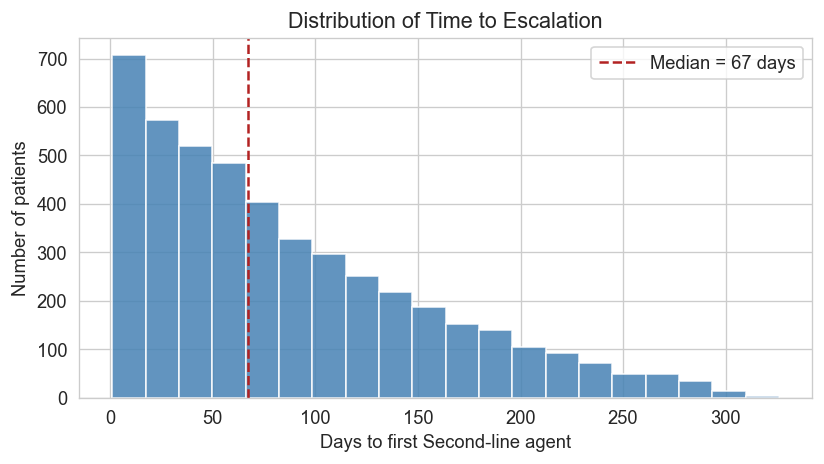

In [50]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    df["time_to_escalation"], bins=20, color="steelblue", edgecolor="white", alpha=0.85
)
ax.axvline(
    df["time_to_escalation"].median(),
    color="firebrick",
    linestyle="--",
    label=f"Median = {df['time_to_escalation'].median():.0f} days",
)
ax.set_xlabel("Days to first Second-line agent")
ax.set_ylabel("Number of patients")
ax.set_title("Distribution of Time to Escalation")
ax.legend()
plt.tight_layout()
plt.show()

### Demographics

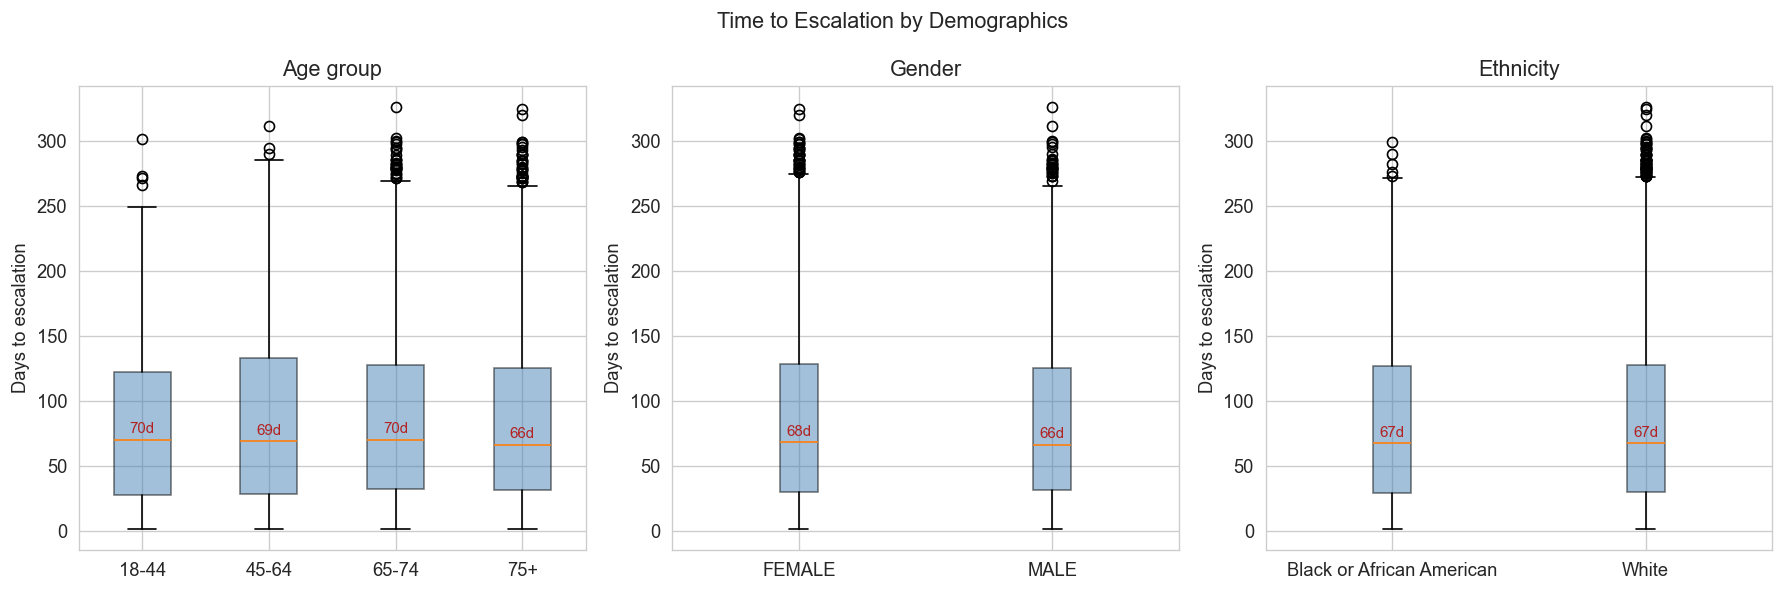

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, col) in zip(
    axes,
    [("Age group", "age_group"), ("Gender", "gender"), ("Ethnicity", "race")],
):
    grouped = df.groupby(col)["time_to_escalation"]
    keys = list(grouped.groups.keys())
    labels = [str(k) for k in keys]
    groups = [grouped.get_group(k).dropna().values for k in keys]
    ax.boxplot(
        groups,
        labels=labels,
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.5),
    )
    ax.set_title(label)
    ax.set_ylabel("Days to escalation")
    ax.tick_params(axis="x")
    medians = grouped.median()
    for i, med in enumerate(medians.values):
        ax.text(i + 1, med + 5, f"{med:.0f}d", ha="center", fontsize=9, color="firebrick")

plt.suptitle("Time to Escalation by Demographics", fontsize=13)
plt.tight_layout()
plt.show()

### Comorbidities

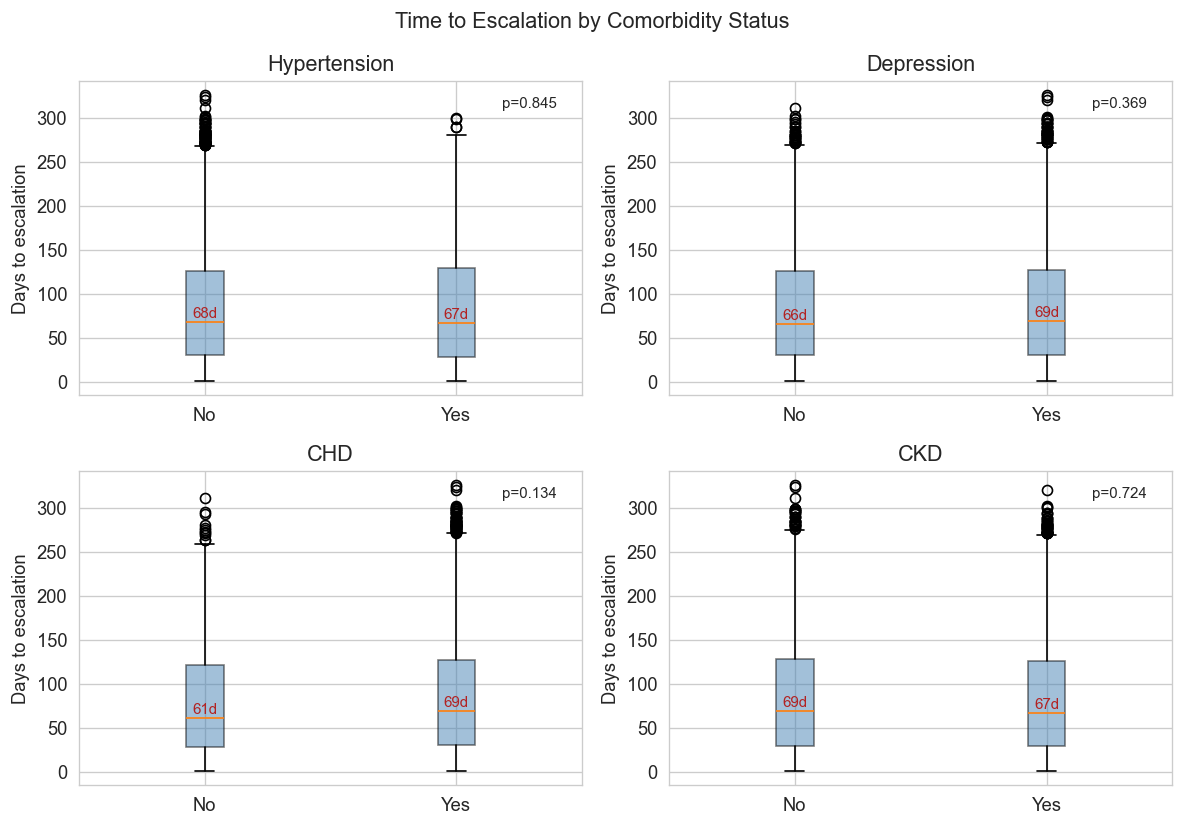

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, (label, col) in zip(
    axes.ravel(),
    [
        ("Hypertension", "hypertension"),
        ("Depression", "depression"),
        ("CHD", "chd"),
        ("CKD", "ckd"),
    ],
):
    data_0 = df[df[col] == 0]["time_to_escalation"]
    data_1 = df[df[col] == 1]["time_to_escalation"]
    ax.boxplot(
        [data_0, data_1],
        labels=["No", "Yes"],
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.5),
    )
    ax.set_title(label)
    ax.set_ylabel("Days to escalation")
    medians = df.groupby(col)["time_to_escalation"].median()
    for i, (grp, med) in enumerate(medians.items()):
        ax.text(i + 1, med + 5, f"{med:.0f}d", ha="center", fontsize=9, color="firebrick")
    if len(data_0) > 0 and len(data_1) > 0:
        stat, p = stats.mannwhitneyu(data_0, data_1, alternative="two-sided")
        ax.text(0.95, 0.95, f"p={p:.3f}", transform=ax.transAxes, ha="right", va="top", fontsize=9)

plt.suptitle("Time to Escalation by Comorbidity Status", fontsize=13)
plt.tight_layout()
plt.show()

### By Diabetes Duration

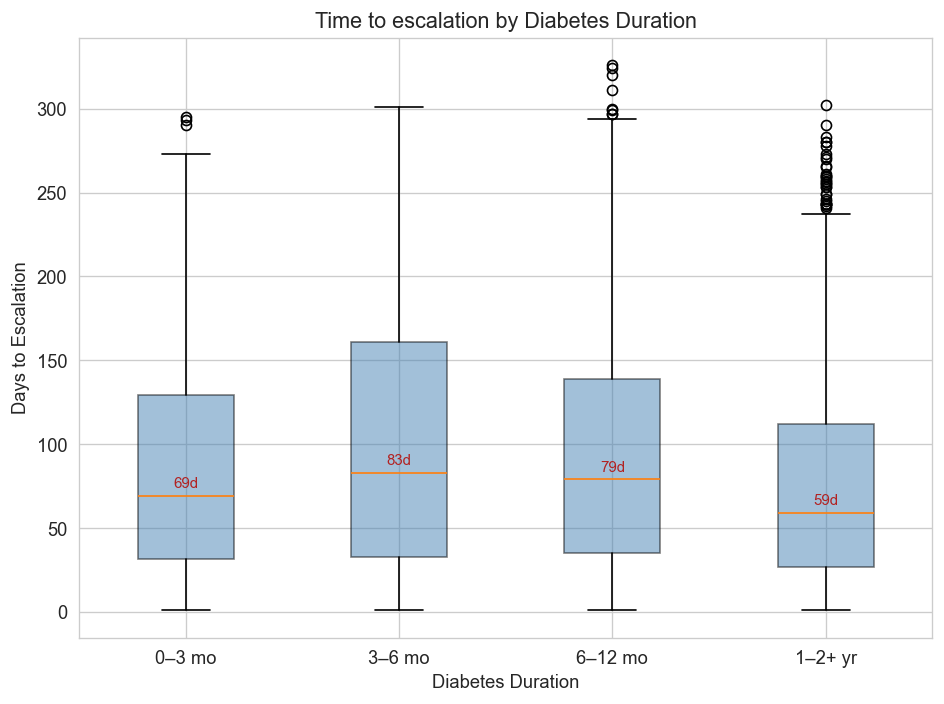

In [53]:
import matplotlib.pyplot as plt
from scipy import stats

order = ["0–3 mo", "3–6 mo", "6–12 mo", "1–2+ yr"]

# Make sure the categories stay in the order you want
df["diabetes_duration"] = pd.Categorical(
    df["diabetes_duration"], categories=order, ordered=True
)

fig, ax = plt.subplots(figsize=(8, 6))

grouped_data = [
    df.loc[df["diabetes_duration"] == grp, "time_to_escalation"].dropna()
    for grp in order
]

medians = {
    grp: df.loc[df["diabetes_duration"] == grp, "time_to_escalation"].median()
    for grp in order
}

ax.boxplot(
    grouped_data,
    labels=order,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.5),
)

ax.set_title("Time to escalation by Diabetes Duration")
ax.set_ylabel("Days to Escalation")
ax.set_xlabel("Diabetes Duration")

# Add median labels
for i, grp in enumerate(order, start=1):
    med = medians[grp]
    if pd.notna(med):
        ax.text(
            i,
            med + 5,
            f"{med:.0f}d",
            ha="center",
            fontsize=9,
            color="firebrick",
        )


plt.tight_layout()
plt.show()

### Diabetes Duration before index date

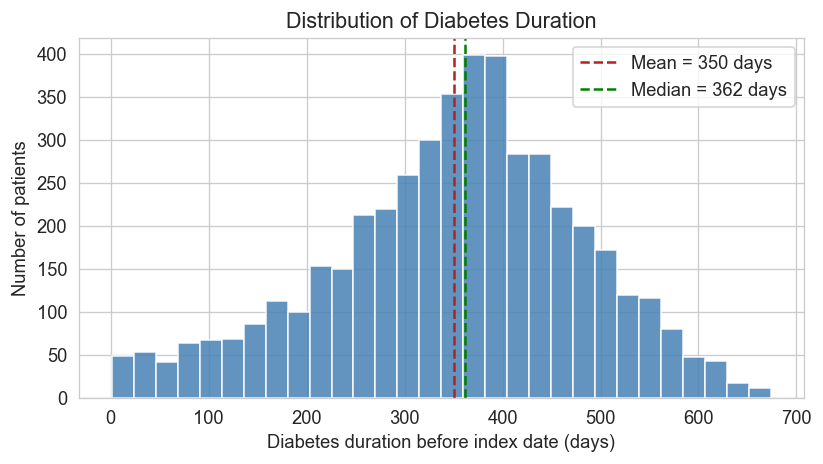

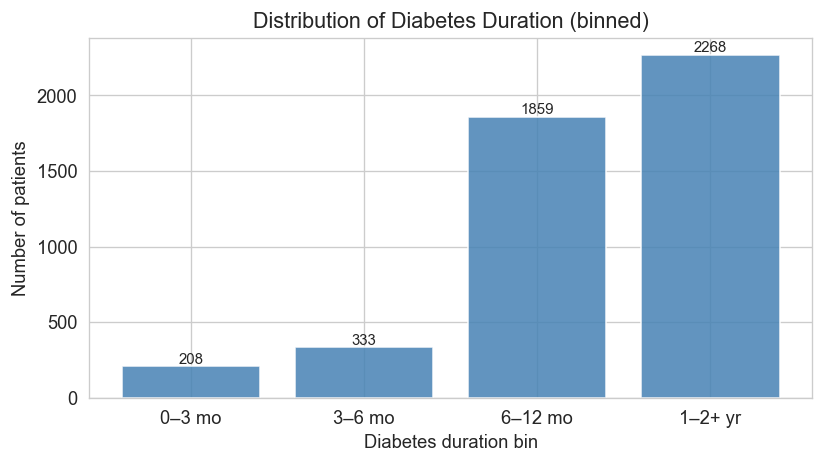

In [59]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    df["diabetes_duration_days"],
    bins=30,
    color="steelblue",
    edgecolor="white",
    alpha=0.85,
)
mean_val = df["diabetes_duration_days"].mean()
median_val = df["diabetes_duration_days"].median()
ax.axvline(
    mean_val,
    color="firebrick",
    linestyle="--",
    label=f"Mean = {mean_val:.0f} days",
)
ax.axvline(
    median_val,
    color="green",
    linestyle="--",
    label=f"Median = {median_val:.0f} days",
)
ax.set_xlabel("Diabetes duration before index date (days)")
ax.set_ylabel("Number of patients")
ax.set_title("Distribution of Diabetes Duration")
ax.legend()
plt.tight_layout()
plt.show()

# --- Bar chart of binned diabetes_duration categories ---
fig, ax = plt.subplots(figsize=(7, 4))
order = ["0–3 mo", "3–6 mo", "6–12 mo", "1–2+ yr"]
counts = df["diabetes_duration"].value_counts().reindex(order)
bars = ax.bar(counts.index, counts.values, color="steelblue", edgecolor="white", alpha=0.85)
for bar, n in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{int(n)}",
            ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Diabetes duration bin")
ax.set_ylabel("Number of patients")
ax.set_title("Distribution of Diabetes Duration (binned)")
plt.tight_layout()
plt.show()


## Top Second-line Drugs

First second-line agent initiated after metformin:
---------------------------------------------
glyburide             n=1825  (39.0%)
glipizide             n=1444  (30.9%)
glimepiride           n=454  (9.7%)
rosiglitazone         n=404  (8.6%)
pioglitazone          n=324  (6.9%)
repaglinide           n= 80  (1.7%)
sitagliptin           n= 78  (1.7%)
nateglinide           n= 49  (1.0%)
insulin glargine      n= 15  (0.3%)
insulin detemir       n=  4  (0.1%)
saxagliptin           n=  2  (0.0%)
                      N=4679


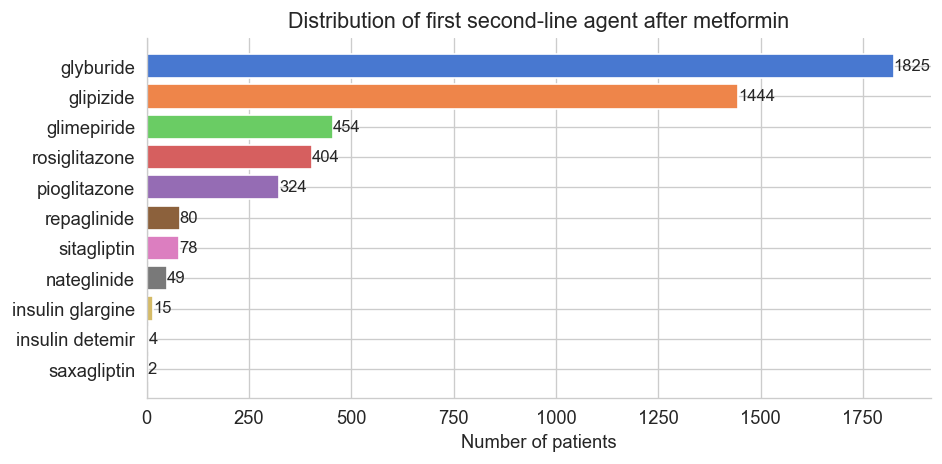

In [55]:
# Top second-line agents (first agent per patient)
drug_counts = df["second_line_drug_name"].value_counts()
drug_pcts = (drug_counts / len(df) * 100).round(1)

print("First second-line agent initiated after metformin:")
print("-" * 45)
for drug, n in drug_counts.items():
    print(f"{drug:<20s}  n={n:>3d}  ({drug_pcts[drug]:.1f}%)")
print(f"{'':20s}  N={drug_counts.sum():>3d}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette("muted", len(drug_counts))
bars = ax.barh(
    drug_counts.index[::-1],
    drug_counts.values[::-1],
    color=colors[::-1],
    edgecolor="white",
)
ax.set_xlabel("Number of patients")
ax.set_title("Distribution of first second-line agent after metformin")
for bar, val in zip(bars, drug_counts.values[::-1]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va="center",
        fontsize=10,
    )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## Comorbidity Co-occurrence

Comorbidity count distribution:
comorbidity_count
0     315
1     972
2    1629
3    1547
4     216
Name: count, dtype: int64

Comorbidity co-occurrence matrix (counts):
              hypertension  depression   chd   ckd
hypertension           467         309   435   313
depression             309        2527  2347  1671
chd                    435        2347  4058  2491
ckd                    313        1671  2491  2683


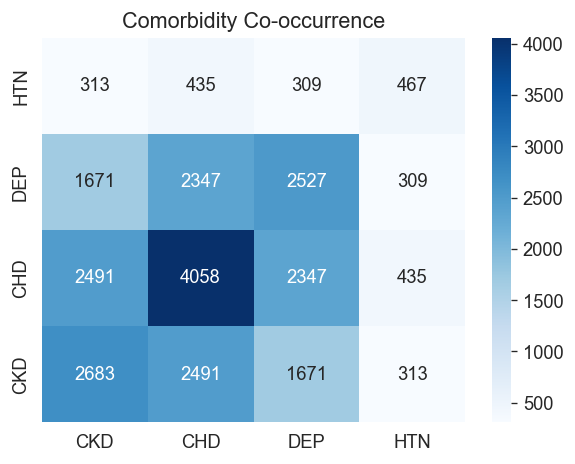

In [61]:
comorbidity_cols = ["hypertension", "depression", "chd", "ckd"]

# Comorbidity count distribution
df["comorbidity_count"] = df[comorbidity_cols].sum(axis=1)
print("Comorbidity count distribution:")
print(df["comorbidity_count"].value_counts().sort_index())
print()

# Co-occurrence matrix
co_matrix = pd.DataFrame(index=comorbidity_cols, columns=comorbidity_cols, dtype=float)
for c1 in comorbidity_cols:
    for c2 in comorbidity_cols:
        if c1 == c2:
            co_matrix.loc[c1, c2] = df[c1].sum()
        else:
            co_matrix.loc[c1, c2] = ((df[c1] == 1) & (df[c2] == 1)).sum()

print("Comorbidity co-occurrence matrix (counts):")
print(co_matrix.astype(int))

# Heatmap — x-axis reversed
x_order = comorbidity_cols[::-1]
co_matrix_flipped = co_matrix[x_order]

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    co_matrix_flipped.astype(int),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    xticklabels=["CKD", "CHD", "DEP", "HTN"],
    yticklabels=["HTN", "DEP", "CHD", "CKD"],
)
ax.set_title("Comorbidity Co-occurrence")
plt.tight_layout()
plt.show()

## Time to Escalation

### By Demographics

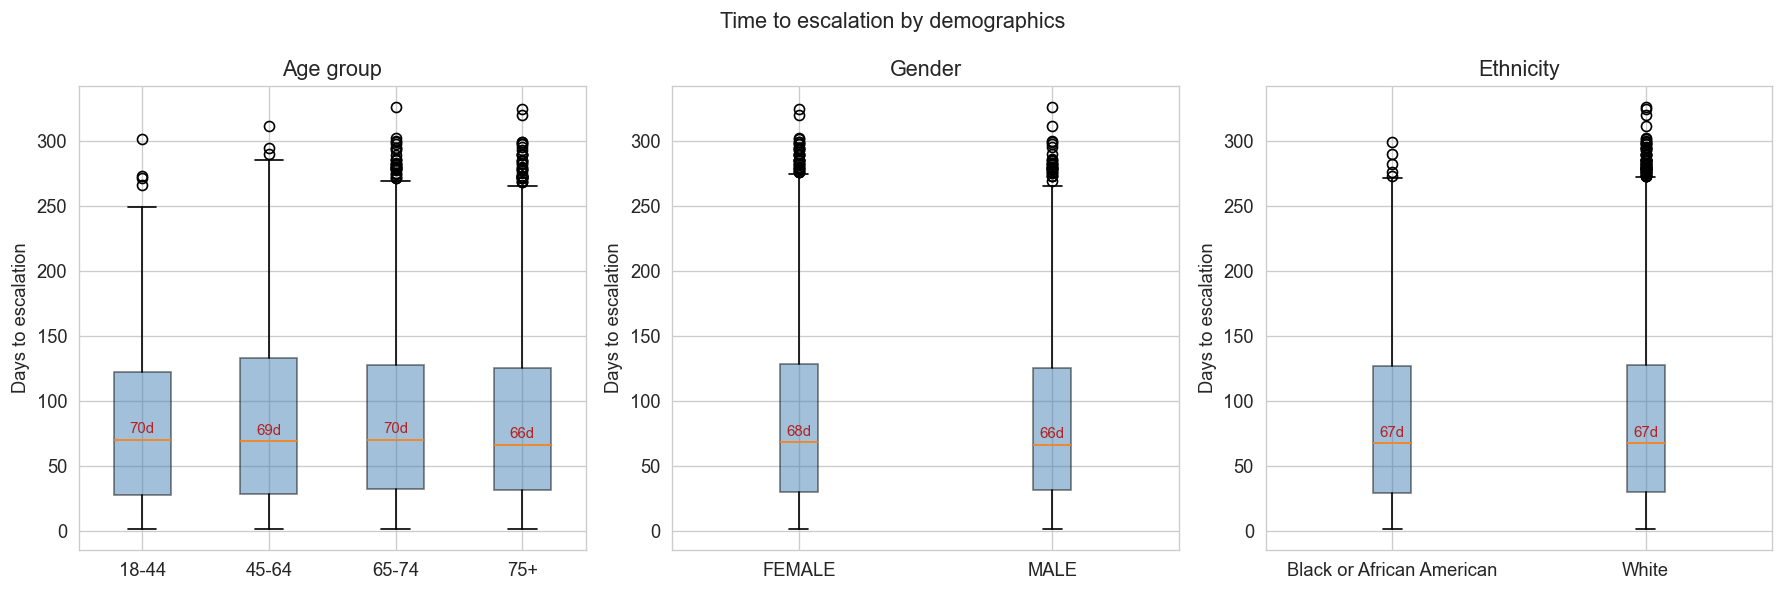

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (label, col) in zip(
    axes,
    [("Age group", "age_group"), ("Gender", "gender"), ("Ethnicity", "race")],
):
    grouped = df.groupby(col)["time_to_escalation"]
    keys = list(grouped.groups.keys())
    labels = [str(k) for k in keys]
    groups = [grouped.get_group(k).dropna().values for k in keys]
    ax.boxplot(
        groups,
        labels=labels,
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.5),
    )
    ax.set_title(label)
    ax.set_ylabel("Days to escalation")
    ax.tick_params(axis="x")
    medians = grouped.median()
    for i, med in enumerate(medians.values):
        ax.text(
            i + 1,
            med + 5,
            f"{med:.0f}d",
            ha="center",
            fontsize=9,
            color="firebrick",
        )
plt.suptitle("Time to escalation by demographics", fontsize=13)
plt.tight_layout()
plt.show()

### By Comorbidities

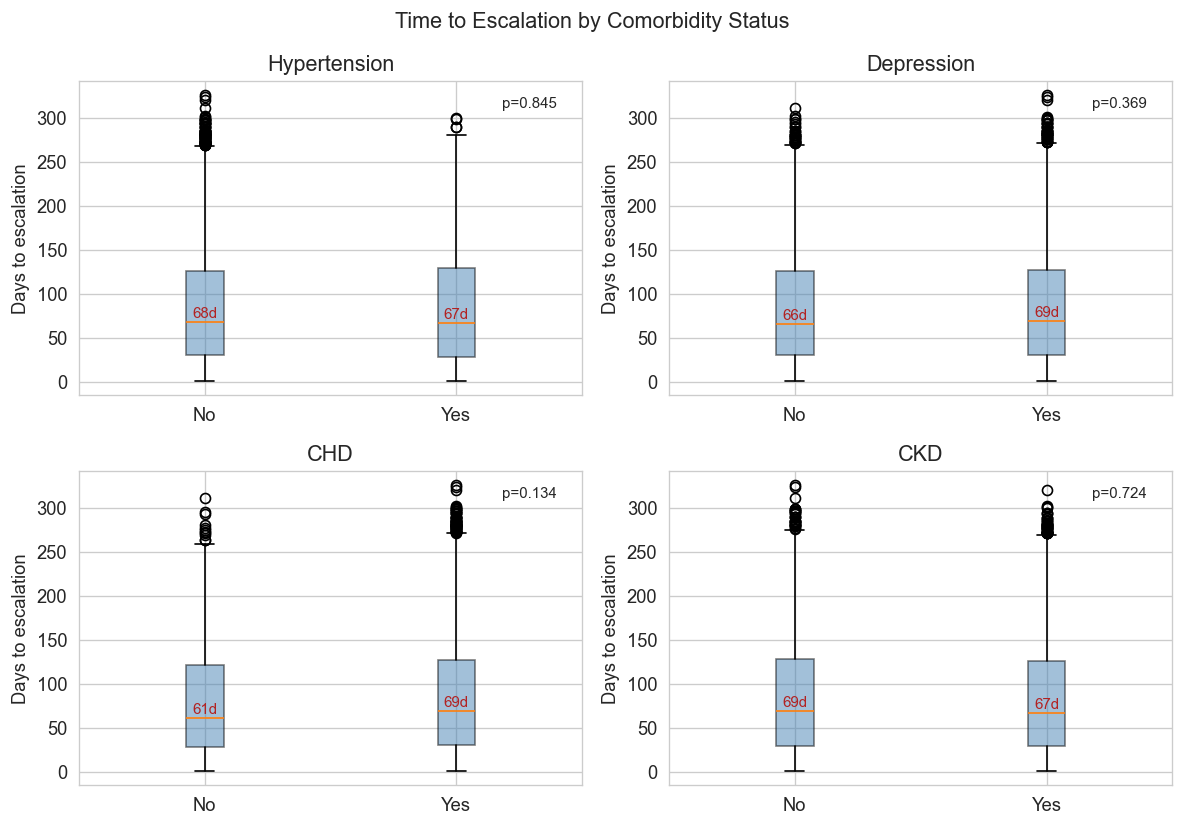

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, (label, col) in zip(
    axes.ravel(),
    [
        ("Hypertension", "hypertension"),
        ("Depression", "depression"),
        ("CHD", "chd"),
        ("CKD", "ckd"),
    ],
):
    data_0 = df[df[col] == 0]["time_to_escalation"]
    data_1 = df[df[col] == 1]["time_to_escalation"]
    ax.boxplot(
        [data_0, data_1],
        labels=["No", "Yes"],
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.5),
    )
    ax.set_title(label)
    ax.set_ylabel("Days to escalation")
    medians = df.groupby(col)["time_to_escalation"].median()
    for i, (grp, med) in enumerate(medians.items()):
        ax.text(i + 1, med + 5, f"{med:.0f}d", ha="center", fontsize=9, color="firebrick")
    if len(data_0) > 0 and len(data_1) > 0:
        stat, p = stats.mannwhitneyu(data_0, data_1, alternative="two-sided")
        ax.text(0.95, 0.95, f"p={p:.3f}", transform=ax.transAxes, ha="right", va="top", fontsize=9)

plt.suptitle("Time to Escalation by Comorbidity Status", fontsize=13)
plt.tight_layout()
plt.show()

### Diabetes Duration

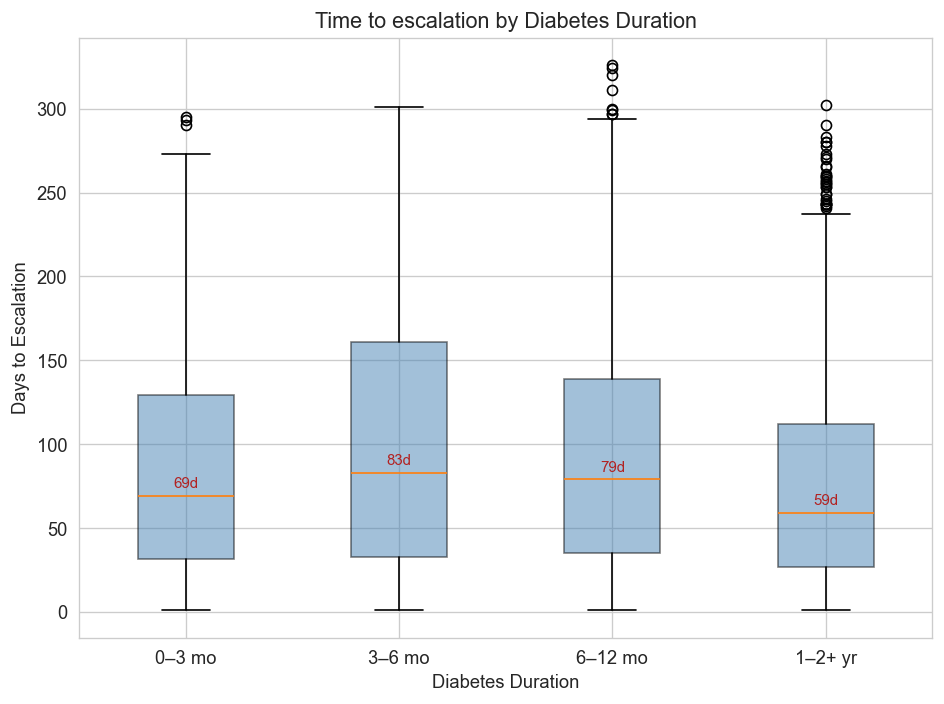

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats

order = ["0–3 mo", "3–6 mo", "6–12 mo", "1–2+ yr"]

# Make sure the categories stay in the order you want
df["diabetes_duration"] = pd.Categorical(
    df["diabetes_duration"], categories=order, ordered=True
)

fig, ax = plt.subplots(figsize=(8, 6))

grouped_data = [
    df.loc[df["diabetes_duration"] == grp, "time_to_escalation"].dropna()
    for grp in order
]

medians = {
    grp: df.loc[df["diabetes_duration"] == grp, "time_to_escalation"].median()
    for grp in order
}

ax.boxplot(
    grouped_data,
    labels=order,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.5),
)

ax.set_title("Time to escalation by Diabetes Duration")
ax.set_ylabel("Days to Escalation")
ax.set_xlabel("Diabetes Duration")

# Add median labels
for i, grp in enumerate(order, start=1):
    med = medians[grp]
    if pd.notna(med):
        ax.text(
            i,
            med + 5,
            f"{med:.0f}d",
            ha="center",
            fontsize=9,
            color="firebrick",
        )

plt.tight_layout()
plt.show()